# Atomistic Simulations with ASE: Classical and ML Potentials

You will use the Atomistic Simulation Environment (ASE) to run atomistic simulations with two interatomic potentials:

| Potential | Type | Notes |
|---|---|---|
| EMT | Classical (semi-empirical) | Fast; fitted to FCC metals only |
| MACE-MP-0b3 | Machine-learning universal potential | Near-DFT accuracy; 89 elements |

Consult the [ASE documentation](https://wiki.fysik.dtu.dk/ase/) whenever you need to look up a function.



## Section 1 - Setup and Imports

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from ase import units
from ase.build import bulk, molecule
from ase.calculators.emt import EMT
from ase.filters import ExpCellFilter
from ase.optimize import BFGS
from ase.eos import EquationOfState
from ase.visualize.plot import plot_atoms
from ase.visualize import view
from mace.calculators import mace_mp
from ase.io import read, write


import ase

print(f"ASE version : {ase.__version__}")

ASE version : 3.28.0


## Section 2 - Building Crystal Structures

ASE represents every structure as an `Atoms` object containing atomic species, positions, and the simulation cell. Use `bulk()` to create periodic crystal structures and `molecule()` for isolated molecules.

```python
# Example: conventional FCC Cu unit cell
cu = bulk('Cu', 'fcc', a=3.6, cubic=True)

print(f'Formula           : {cu.get_chemical_formula()}')
print(f'Number of atoms   : {len(cu)}')
print(f'Lattice constant  : {cu.cell[0, 0]:.3f} Å')
print(f'Volume per atom   : {cu.get_volume() / len(cu):.3f} Å³')
# 3d visualization of the structure
view(cu, viewer="x3d") # Check the viewer option, try also "ngl" or "ase"
```

### Task - Explore structures

1. Create a **2×2×2 supercell** of FCC Cu (`a = 3.6 Å`) and print the number of atoms.
2. Create bulk **MgO** (rocksalt, `a = 4.21 Å`) and print its formula, number of atoms, and volume per formula unit.
3. Create a **CO₂ molecule** and print the C–O bond length `co2.get_distances...`.
4. Read the  `PE_chains_POSCAR` file with ase and visualize the structure with `view`. What do you see? Also, open the file in VScode and inspect its contents. Leave your observations in the cell below.

## Section 3 - Calculators, Energies, and Geometry Optimisation

Attach an interatomic potential to a structure via `atoms.calc = ...`. Once attached, you can query energies, forces, and stresses. 

```python
atoms.get_potential_energy() # total energy in eV
atoms.get_forces() # forces on each atom in eV/Å
atoms.get_stress() # Voigt stress tensor in eV/Å³
```

Potential: **EMT** (Effective Medium Theory) is a fast semi-empirical **IP** shipped with ASE.
It supports the FCC metals Cu, Ag, Au, Ni, Pd, Pt, and Al.

To optimise both atomic positions and the cell shape simultaneously, wrap the structure in `ExpCellFilter` before passing it to `BFGS`.



### Task  - Visualise forces and relax a structure

1. Build FCC Cu with `a = 3.6 Å`, displace one atom by 0.2 Å along *x* (hint: you can modify the positions via `atoms.positions[...]`), attach `EMT()` IP, and plot the structure with `plot_atoms` or `view(, viewer="x3d")`.
2. Build a fresh Cu cell with `a = 3.7 Å`, attach `EMT()`, and relax it (positions **and** cell) until all forces are below 0.01 eV/Å. Print the relaxed lattice constant and energy per atom. You need to use `ExpCellFilter` to relax the cell shape as well as atomic positions and the `BFGS` optimizer (e.g., `BFGS(ecf, logfile=None).run(fmax=0.01)`)

In [ ]:
# Task 


## Section 4 - Equation of State

The equation of state (EOS) relates total energy $E$ to cell volume $V$. Fitting the Birch–Murnaghan model to an $E(V)$ curve gives the equilibrium volume $V_0$, ground-state energy $E_0$, and bulk modulus $B_0$. Use `EquationOfState` from `ase.eos` and convert $B_0$ from eV/Å³ to GPa via `B / units.kJ * 1e24`.

### Task - Energy–volume curve and EOS fit (EMT)

Starting from the relaxed Cu cell (Task before), scale the unit cell over a range of volumes, compute the energy at each volume with EMT, fit the Birch–Murnaghan EOS, and report the equilibrium lattice constant $a_0$ and bulk modulus $B_0$ in GPa. Plot the fitted curve.

Loop over 11 scale factors `s` in `np.linspace(0.94, 1.06, 11)`

Example 
```python
eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
v0, e0, B = eos.fit()          # B in eV/Å³
B_GPa = B / units.kJ * 1e24   # convert to GPa
eos.plot()
```

In [ ]:
# Task 


## Section 5 — MACE-MP-0b3: A Universal ML Potential

MACE-MP-0b3 is a message-passing neural network potential trained on ~1.6 M DFT calculations covering 89 elements. It is used as a drop-in ASE calculator. The cell below loads the model — re-use the `calc_mace` object throughout; do not re-instantiate it inside loops.

In [ ]:
calc_mace = mace_mp(
    model='medium-0b3',
    dispersion=False,
    default_dtype='float32',
    device='cpu',
)
print('MACE-MP-0b3 ready.')

### Task - Relax Cu with MACE-MP-0b3

Starting from `a = 3.7 Å`, relax FCC Cu (positions and cell) with MACE-MP-0b3. Print the relaxed lattice constant and compare it to the EMT result. Again, wrap in `ExpCellFilter` and relax with `BFGS`.

In [ ]:
# Task 


### Task  - EOS with MACE-MP-0b3

Repeat the EOS calculation from Task 3 using MACE-MP-0b3. Report $a_0$ and $B_0$.

In [ ]:
# Task 


## Section 6 - Comparison

Experimental reference values for Cu: $a_0 = 3.615$ Å, $B_0 = 133$ GPa.

### Task - Side-by-side comparison

1. Print a table comparing $a_0$ and $B_0$ for EMT, MACE-MP-0b3, and experiment.
2. Plot both $E$–$V$ curves (normalised to eV/atom) on one figure with a legend, axis labels, and vertical dashed lines marking each $V_0$.

In [ ]:
# Task


Solution:

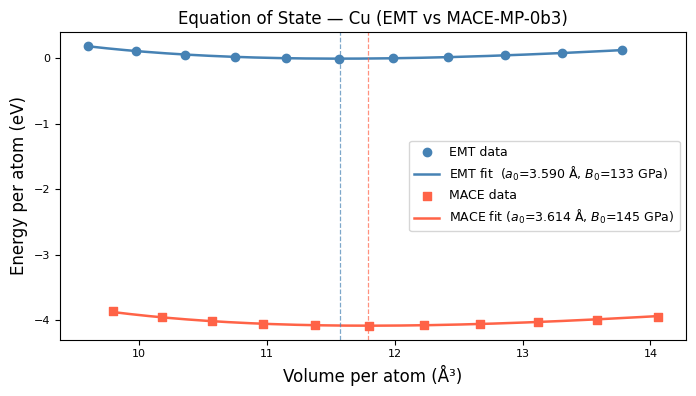

## Section 7 - High-Throughput Bulk Modulus Screening

Universal ML potentials make high-throughput screening straightforward: one calculator, any material.

Compute time: ~9 evaluations × 100 crystals ≈ 5 min on CPU. 

In [9]:
# (label, formula, crystal_structure, a [Å], extra_kwargs)
# HCP entries carry {'covera': c/a}; all others use cubic=True.
CRYSTALS = [
    # --- FCC metals (20) ---
    ("Cu", "Cu", "fcc", 3.615, {}),
    ("Ag", "Ag", "fcc", 4.085, {}),
    ("Au", "Au", "fcc", 4.078, {}),
    ("Al", "Al", "fcc", 4.049, {}),
    ("Ni", "Ni", "fcc", 3.524, {}),
    ("Pd", "Pd", "fcc", 3.891, {}),
    ("Pt", "Pt", "fcc", 3.924, {}),
    ("Ir", "Ir", "fcc", 3.840, {}),
    ("Rh", "Rh", "fcc", 3.803, {}),
    ("Pb", "Pb", "fcc", 4.950, {}),
    ("Ca", "Ca", "fcc", 5.588, {}),
    ("Sr", "Sr", "fcc", 6.084, {}),
    ("Th", "Th", "fcc", 5.084, {}),
    ("Ce", "Ce", "fcc", 5.161, {}),
    ("Yb", "Yb", "fcc", 5.485, {}),
    ("Ne", "Ne", "fcc", 4.430, {}),
    ("Ar", "Ar", "fcc", 5.311, {}),
    ("Kr", "Kr", "fcc", 5.721, {}),
    ("Xe", "Xe", "fcc", 6.197, {}),
    ("Ac", "Ac", "fcc", 5.310, {}),
    # --- BCC metals (14) ---
    ("Fe", "Fe", "bcc", 2.870, {}),
    ("W", "W", "bcc", 3.165, {}),
    ("Mo", "Mo", "bcc", 3.147, {}),
    ("Cr", "Cr", "bcc", 2.884, {}),
    ("V", "V", "bcc", 3.028, {}),
    ("Nb", "Nb", "bcc", 3.300, {}),
    ("Ta", "Ta", "bcc", 3.303, {}),
    ("Li", "Li", "bcc", 3.510, {}),
    ("Na", "Na", "bcc", 4.225, {}),
    ("K", "K", "bcc", 5.225, {}),
    ("Rb", "Rb", "bcc", 5.585, {}),
    ("Ba", "Ba", "bcc", 5.020, {}),
    ("Cs", "Cs", "bcc", 6.141, {}),
    ("Eu", "Eu", "bcc", 4.583, {}),
    # --- HCP metals (14) ---
    ("Mg", "Mg", "hcp", 3.209, {"covera": 1.624}),
    ("Ti", "Ti", "hcp", 2.951, {"covera": 1.586}),
    ("Zr", "Zr", "hcp", 3.232, {"covera": 1.593}),
    ("Hf", "Hf", "hcp", 3.196, {"covera": 1.582}),
    ("Co", "Co", "hcp", 2.507, {"covera": 1.632}),
    ("Zn", "Zn", "hcp", 2.665, {"covera": 1.856}),
    ("Cd", "Cd", "hcp", 2.979, {"covera": 1.886}),
    ("Be", "Be", "hcp", 2.286, {"covera": 1.568}),
    ("Os", "Os", "hcp", 2.734, {"covera": 1.579}),
    ("Ru", "Ru", "hcp", 2.706, {"covera": 1.582}),
    ("Re", "Re", "hcp", 2.760, {"covera": 1.615}),
    ("Sc", "Sc", "hcp", 3.309, {"covera": 1.592}),
    ("Y", "Y", "hcp", 3.648, {"covera": 1.571}),
    ("Lu", "Lu", "hcp", 3.505, {"covera": 1.583}),
    # --- Diamond / cubic semiconductors (4) ---
    ("C", "C", "diamond", 3.567, {}),
    ("Si", "Si", "diamond", 5.431, {}),
    ("Ge", "Ge", "diamond", 5.658, {}),
    ("Sn", "Sn", "diamond", 6.489, {}),
    # --- Rocksalt (31) ---
    ("MgO", "MgO", "rocksalt", 4.211, {}),
    ("CaO", "CaO", "rocksalt", 4.810, {}),
    ("BaO", "BaO", "rocksalt", 5.539, {}),
    ("SrO", "SrO", "rocksalt", 5.160, {}),
    ("NiO", "NiO", "rocksalt", 4.177, {}),
    ("CoO", "CoO", "rocksalt", 4.261, {}),
    ("MnO", "MnO", "rocksalt", 4.444, {}),
    ("FeO", "FeO", "rocksalt", 4.332, {}),
    ("TiO", "TiO", "rocksalt", 4.177, {}),
    ("NaCl", "NaCl", "rocksalt", 5.640, {}),
    ("KCl", "KCl", "rocksalt", 6.290, {}),
    ("KBr", "KBr", "rocksalt", 6.600, {}),
    ("LiF", "LiF", "rocksalt", 4.027, {}),
    ("NaF", "NaF", "rocksalt", 4.634, {}),
    ("NaI", "NaI", "rocksalt", 6.473, {}),
    ("KF", "KF", "rocksalt", 5.347, {}),
    ("CaS", "CaS", "rocksalt", 5.690, {}),
    ("MgS", "MgS", "rocksalt", 5.200, {}),
    ("PbS", "PbS", "rocksalt", 5.936, {}),
    ("AgF", "AgF", "rocksalt", 4.936, {}),
    ("MgSe", "MgSe", "rocksalt", 5.460, {}),
    ("BaS", "BaS", "rocksalt", 6.390, {}),
    ("SrS", "SrS", "rocksalt", 6.020, {}),
    ("LiCl", "LiCl", "rocksalt", 5.130, {}),
    ("LiBr", "LiBr", "rocksalt", 5.501, {}),
    ("LiI", "LiI", "rocksalt", 6.000, {}),
    ("NaBr", "NaBr", "rocksalt", 5.973, {}),
    ("AgCl", "AgCl", "rocksalt", 5.549, {}),
    ("AgBr", "AgBr", "rocksalt", 5.773, {}),
    ("CsF", "CsF", "rocksalt", 6.014, {}),
    ("RbCl", "RbCl", "rocksalt", 6.590, {}),
    # --- Zinc-blende (10) ---
    ("GaAs", "GaAs", "zincblende", 5.653, {}),
    ("InAs", "InAs", "zincblende", 6.058, {}),
    ("AlAs", "AlAs", "zincblende", 5.660, {}),
    ("GaP", "GaP", "zincblende", 5.450, {}),
    ("InP", "InP", "zincblende", 5.869, {}),
    ("ZnS", "ZnS", "zincblende", 5.420, {}),
    ("ZnSe", "ZnSe", "zincblende", 5.668, {}),
    ("CdS", "CdS", "zincblende", 5.825, {}),
    ("CdTe", "CdTe", "zincblende", 6.482, {}),
    ("BN", "BN", "zincblende", 3.616, {}),
    # --- Fluorite (7) ---
    ("CaF2", "CaF2", "fluorite", 5.463, {}),
    ("BaF2", "BaF2", "fluorite", 6.200, {}),
    ("SrF2", "SrF2", "fluorite", 5.800, {}),
    ("CeO2", "CeO2", "fluorite", 5.411, {}),
    ("ThO2", "ThO2", "fluorite", 5.600, {}),
    ("SrCl2", "SrCl2", "fluorite", 6.977, {}),
    ("PbF2", "PbF2", "fluorite", 6.002, {}),
]

### Task 7 — High-throughput $B_0$ screening

Using MACE-MP-0b3, compute the bulk modulus for all 100 crystals in `CRYSTALS`. Plot a sorted horizontal bar chart coloured by crystal family and identify the 5 hardest and 5 softest materials. Handle failures gracefully.

In [10]:
FAMILY_COLORS = {
    "fcc": "steelblue",
    "bcc": "tomato",
    "hcp": "mediumseagreen",
    "diamond": "orchid",
    "rocksalt": "sandybrown",
    "zincblende": "gold",
    "fluorite": "lightcoral",
}

results = {}  # label -> B0_GPa
families = {}  # label -> structure string

for label, formula, structure, a, extra in CRYSTALS:
    try:
        pass
        # create the atoms object and compute eos
    except Exception as e:
        print(f"{label:8s}: FAILED — {e}")

You should see something like:
```
Cu       (fcc       ): B₀ =  144.5 GPa
Ag       (fcc       ): B₀ =   85.2 GPa
Au       (fcc       ): B₀ =  128.9 GPa
Al       (fcc       ): B₀ =   60.4 GPa
Ni       (fcc       ): B₀ =  194.3 GPa
Pd       (fcc       ): B₀ =  157.8 GPa
Pt       (fcc       ): B₀ =  245.5 GPa
Ir       (fcc       ): B₀ =  348.3 GPa
...
```